In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("/Users/andreali/Documents/Subgraph_Federated_Learning")
    
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from andrea.multigraph_generation import TASKS
print(TASKS)
csv_path = ROOT / "andrea/test_generation_parameters.csv"
print(csv_path)
df = pd.read_csv(csv_path)

['cycle2', 'cycle3', 'cycle4', 'cycle5', 'cycle6']
/Users/andreali/Documents/Subgraph_Federated_Learning/andrea/test_generation_parameters.csv


In [2]:
tasks = set()
for col in df.columns:
    if col.startswith("train_") and col.endswith("_pos_rate"):
        tasks.add(col[len("train_") : -len("_pos_rate")])
    if col.startswith("train_") and col.endswith("_motif_count"):
        tasks.add(col[len("train_") : -len("_motif_count")])
tasks = sorted(tasks)
print(tasks == TASKS)

True


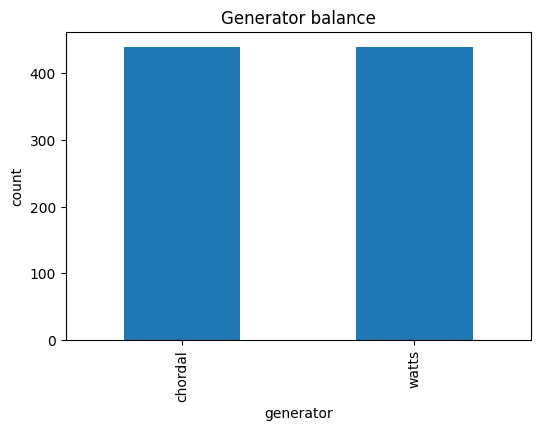

In [3]:
vc = df["type"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
vc.plot(kind="bar")
plt.title("Generator balance")
plt.xlabel("generator")
plt.ylabel("count")
plt.show()

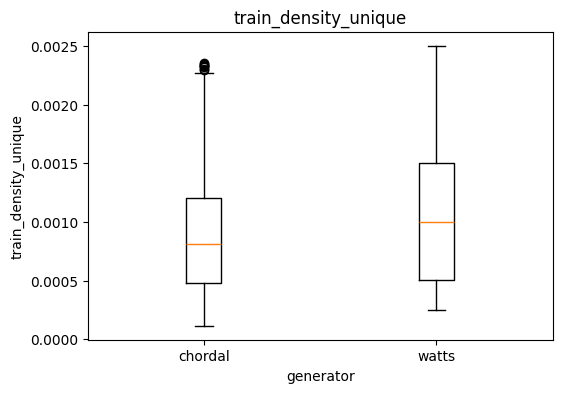

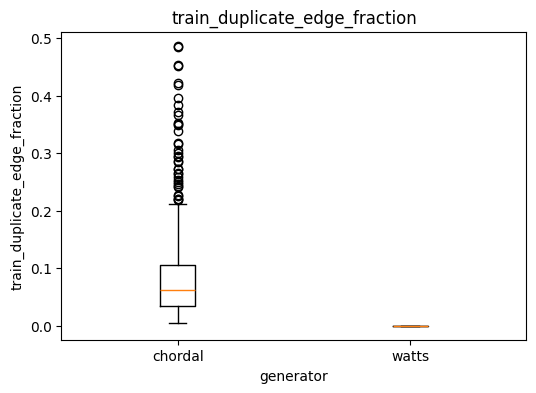

In [4]:
cols = [c for c in ["train_density_unique", "train_duplicate_edge_fraction"] if c in df.columns]
for col in cols:
    plt.figure(figsize=(6, 4))
    data = [df.loc[df["type"] == g, col].dropna().values for g in sorted(df["type"].unique())]
    labels = sorted(df["type"].unique())
    plt.boxplot(data, tick_labels=labels)
    plt.title(col)
    plt.xlabel("generator")
    plt.ylabel(col)

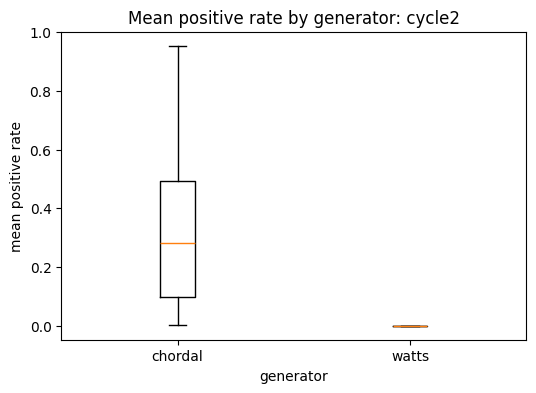

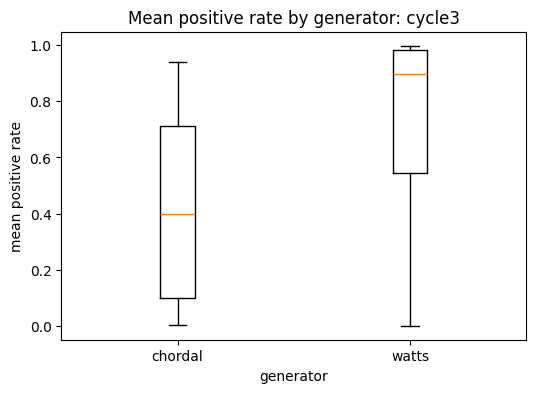

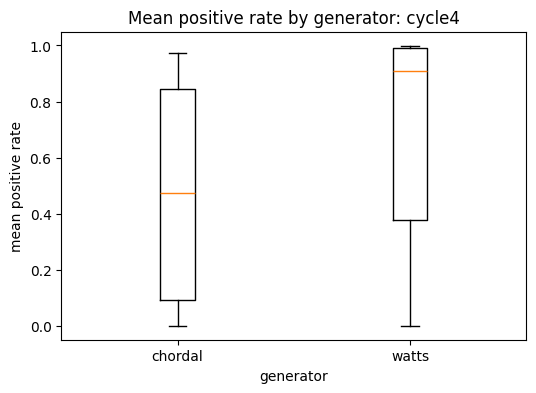

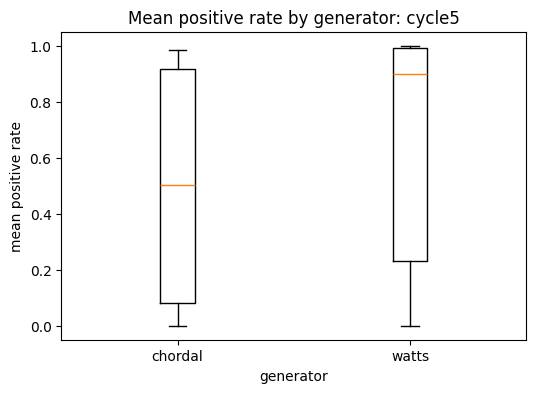

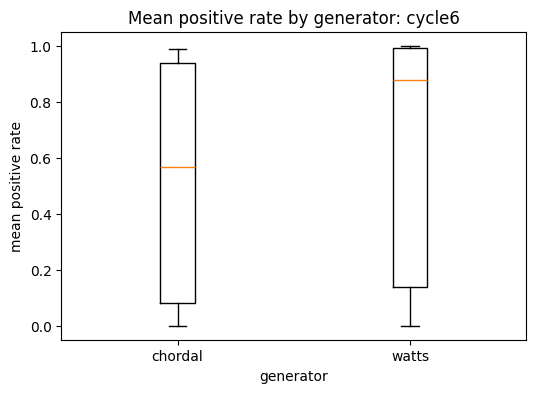

In [5]:
for task in tasks:
    if f"{task}_pos_rate_mean" in df.columns:
        col = f"{task}_pos_rate_mean"
        ylabel = "mean positive rate"
        title = f"Mean positive rate by generator: {task}"
    elif f"train_{task}_motif_count" in df.columns:
        col = f"train_{task}_motif_count"
        ylabel = "train motif count"
        title = f"Train motif count by generator: {task}"
    else:
        continue
    plt.figure(figsize=(6, 4))
    data = [df.loc[df["type"] == g, col].dropna().values for g in sorted(df["type"].unique())]
    labels = sorted(df["type"].unique())
    plt.boxplot(data, tick_labels=labels)
    plt.title(title)
    plt.xlabel("generator")
    plt.ylabel(ylabel)

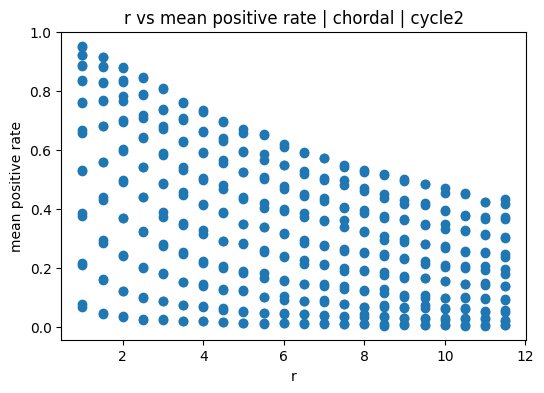

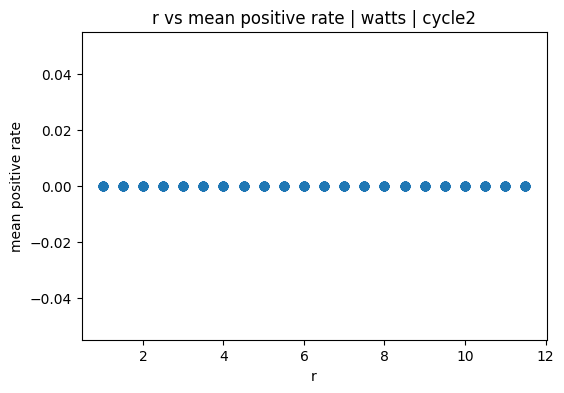

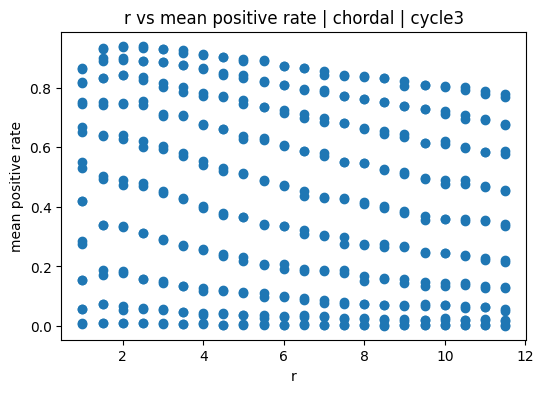

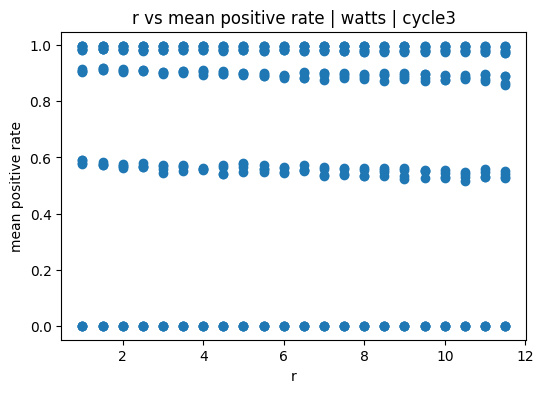

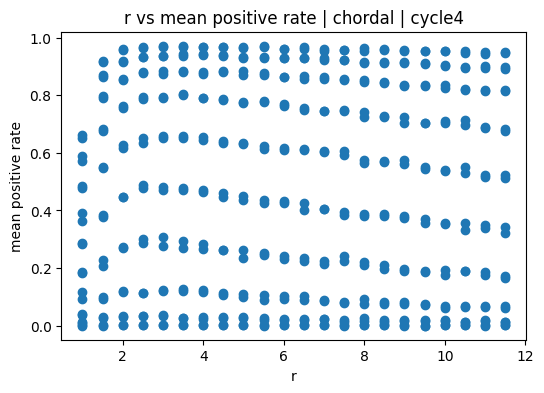

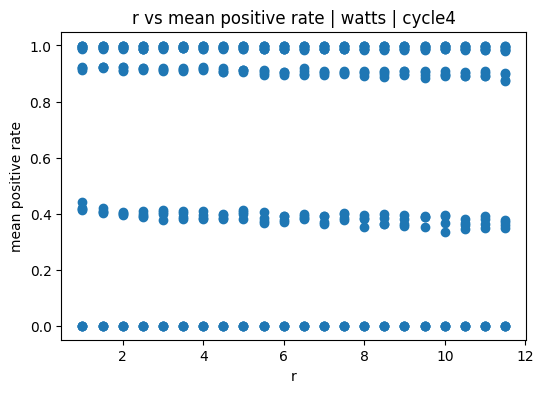

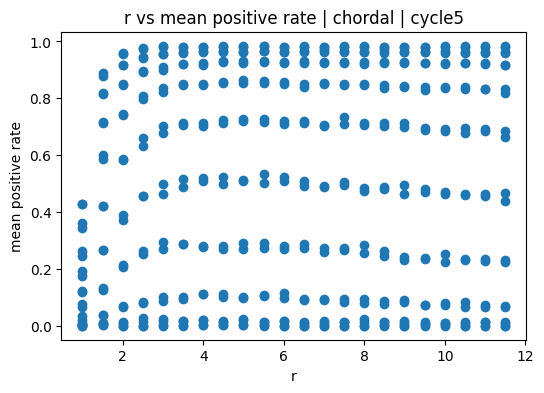

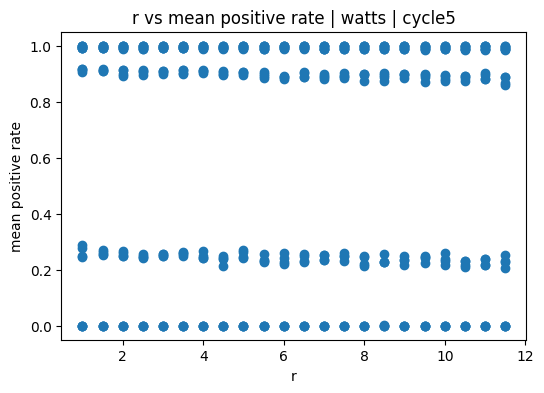

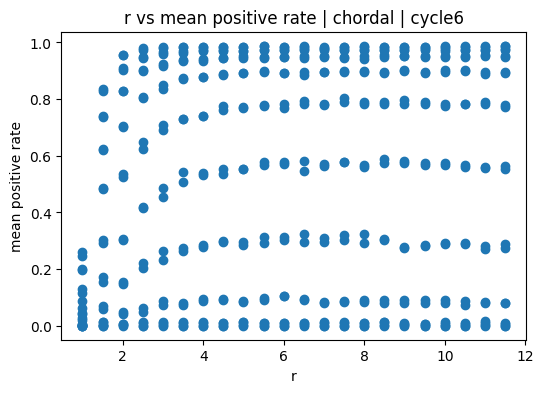

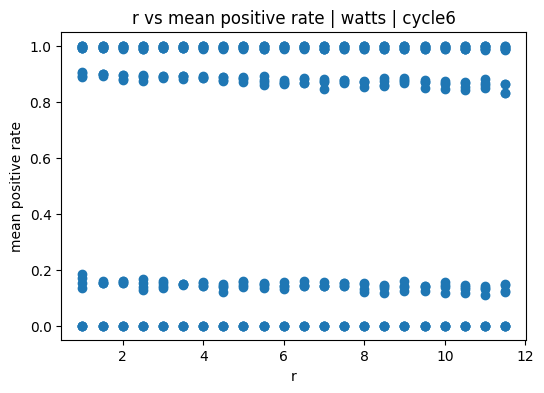

In [6]:
generators = sorted(df["type"].unique())
for task in tasks:
    col = f"{task}_pos_rate_mean"
    if col not in df.columns:
        continue
    for gen in generators:
        sub = df[df["type"] == gen].copy()
        if sub.empty:
            continue
        plt.figure(figsize=(6, 4))
        plt.scatter(sub["r"], sub[col])
        plt.title(f"r vs mean positive rate | {gen} | {task}")
        plt.xlabel("r")
        plt.ylabel("mean positive rate")

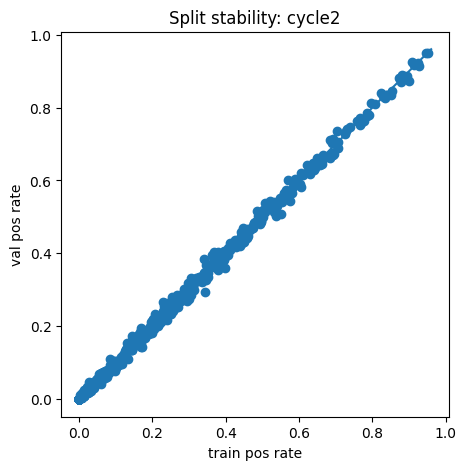

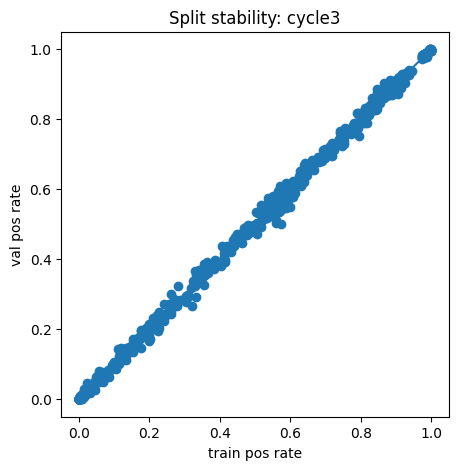

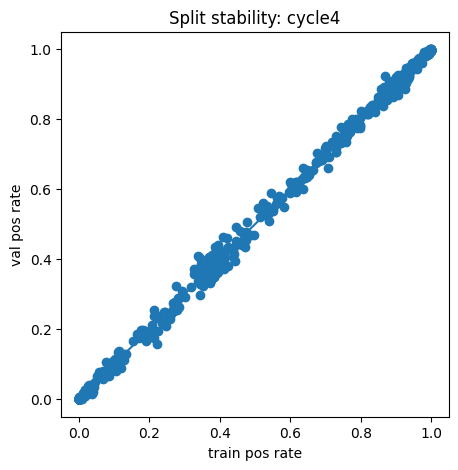

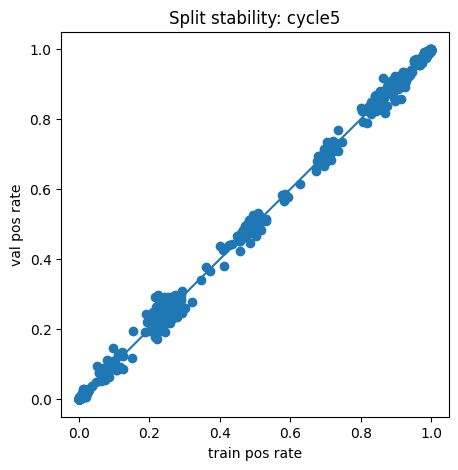

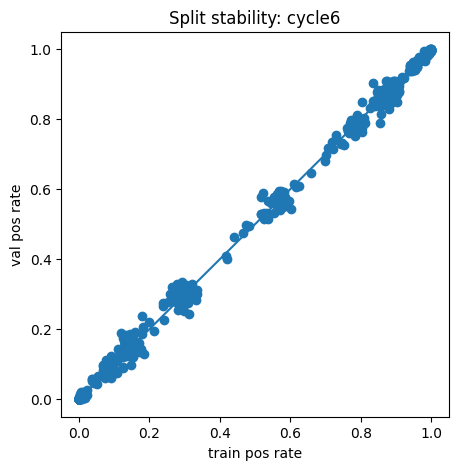

In [7]:
for task in tasks:
    cols = [f"{split_name}_{task}_pos_rate" for split_name in ["train", "val", "test"]]
    if not all(c in df.columns for c in cols):
        continue
    x = df[cols[0]].values
    y = df[cols[1]].values
    z = df[cols[2]].values
    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, label="train vs val")
    lim = [0, max(np.nanmax(x), np.nanmax(y), np.nanmax(z), 0.01)]
    plt.plot(lim, lim)
    plt.xlabel("train pos rate")
    plt.ylabel("val pos rate")
    plt.title(f"Split stability: {task}")
    plt.show()

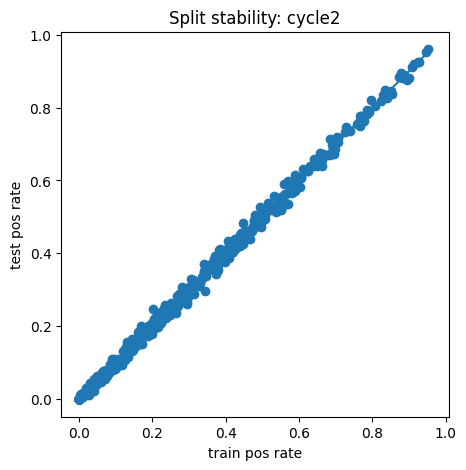

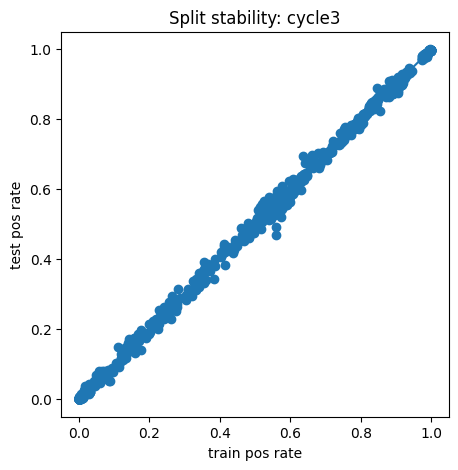

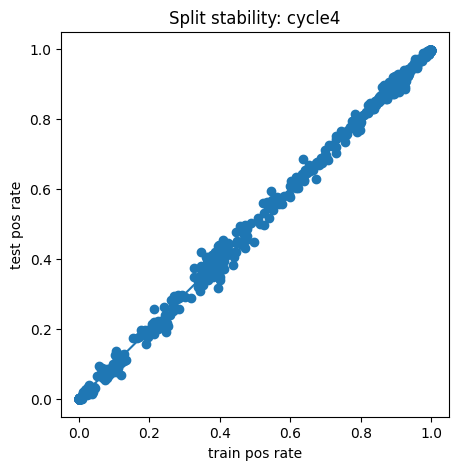

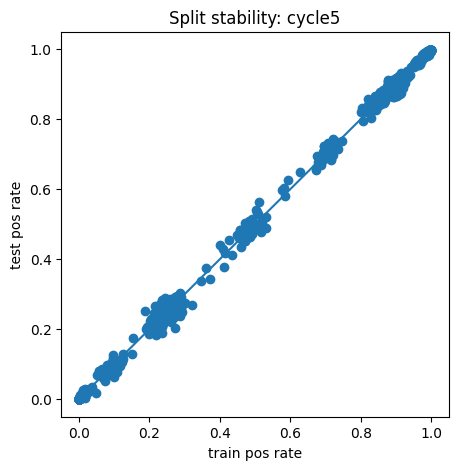

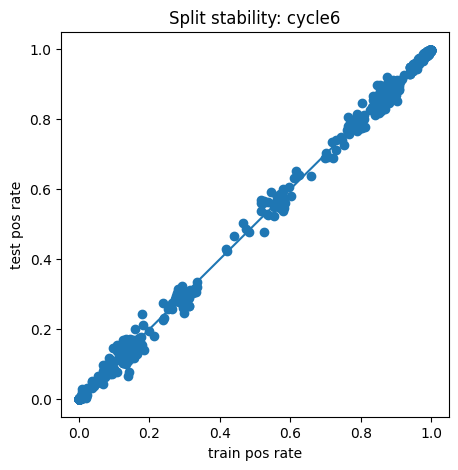

In [8]:
for task in tasks:
    cols = [f"{split_name}_{task}_pos_rate" for split_name in ["train", "val", "test"]]
    if not all(c in df.columns for c in cols):
        continue
    x = df[cols[0]].values
    y = df[cols[1]].values
    z = df[cols[2]].values
    plt.figure(figsize=(5, 5))
    plt.scatter(x, z, label="train vs test")
    lim = [0, max(np.nanmax(x), np.nanmax(y), np.nanmax(z), 0.01)]
    plt.plot(lim, lim)
    plt.xlabel("train pos rate")
    plt.ylabel("test pos rate")
    plt.title(f"Split stability: {task}")
    plt.show()

In [9]:
def show_selected_overview(selected, tasks):
    if isinstance(selected, pd.DataFrame):
        row = selected.iloc[0]
    else:
        row = selected

    meta_cols = ["graph_id", "dataset_id", "type", "selected_profile"]
    for col in meta_cols:
        print(f"{col}: ", row[col])

    records = []
    for task in tasks:

        rec = {
            "task": task,
            "pos_rate_mean": row.get(f"{task}_pos_rate_mean", pd.NA),
            "pos_rate_max_diff_from_mean": row.get(
                f"{task}_pos_rate_max_diff_from_mean", pd.NA
            ),
            "pos_nodes_mean": row.get(f"{task}_pos_nodes_mean", pd.NA),
            "pos_nodes_max_diff_from_mean": row.get(
                f"{task}_pos_nodes_max_diff_from_mean", pd.NA
            ),
        }
        records.append(rec)

    overview = pd.DataFrame(records)

    for c in [
        "pos_rate_mean",
        "pos_rate_max_diff_from_mean",
        "pos_nodes_mean",
        "pos_nodes_max_diff_from_mean",
    ]:
        if c in overview.columns:
            overview[c] = pd.to_numeric(overview[c], errors="coerce").round(3)

    display(overview)
    print("\n")
    return overview

In [17]:
profiles = {
    "increasing": np.array([0.15, 0.20, 0.35, 0.45, 0.55], dtype=float),
    "flat": np.array([0.4, 0.40, 0.40, 0.40, 0.40], dtype=float),
    "decreasing": np.array([0.55, 0.45, 0.35, 0.25, 0.15], dtype=float),
}

# require positive nodes in all splits for all tasks
pos_conditions = []
for task in tasks:    
    pos_conditions.append(df[f"{task}_all_splits_have_pos"])

df["all_splits_have_pos"] = np.logical_and.reduce(pos_conditions)

pos_nodes_cols = []
mean_rate_cols = []
max_diff_mean_rate_cols = []

for task in tasks:
    pos_nodes_cols.append(f"{task}_pos_nodes_mean")
    pos_nodes_cols.append(f"{task}_pos_nodes_max_diff_from_mean")

    mean_rate_cols.append(f"{task}_pos_rate_mean")
    max_diff_mean_rate_cols.append(f"{task}_pos_rate_max_diff_from_mean")

# only keep rows with positives everywhere
valid = df[df["all_splits_have_pos"]].copy()
valid = valid[valid["train_num_nodes"] == 4000]
print(len(valid))

# add MAE columns
for profile_name, target in profiles.items():
    valid[f"mae_{profile_name}"] = valid[mean_rate_cols].apply(
        lambda row: np.mean(np.abs(row.values.astype(float) - target)),
        axis=1,
    )

selected_parts = []
for profile_name in profiles:
    sub = valid.sort_values(f"mae_{profile_name}", ascending=True).head(1).copy()
    sub["selected_profile"] = profile_name
    selected_parts.append(sub)

for selected in selected_parts:
    show_selected_overview(selected, TASKS)

selected_df = pd.concat(selected_parts, ignore_index=True)
selected_df.to_csv("graphs_profile_selected.csv", index=False)

197
graph_id:  1
dataset_id:  data_4000_5_11.5_chordal
type:  chordal
selected_profile:  increasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.139,0.007,556.667,26.667
1,cycle3,0.220,0.008,879.667,31.333
2,cycle4,0.342,0.013,1368.667,51.667
3,cycle5,0.466,0.015,1864.667,58.667
4,cycle6,0.563,0.013,2252.000,52.000




graph_id:  141
dataset_id:  data_4000_5_2.5_chordal
type:  chordal
selected_profile:  flat


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.441,0.012,1765.667,46.667
1,cycle3,0.468,0.020,1873.333,80.667
2,cycle4,0.479,0.018,1916.000,71.000
3,cycle5,0.455,0.031,1819.333,124.333
4,cycle6,0.418,0.010,1674.000,38.000




graph_id:  467
dataset_id:  data_4000_5_1.5_chordal
type:  chordal
selected_profile:  decreasing


,task,pos_rate_mean,pos_rate_max_diff_from_mean,pos_nodes_mean,pos_nodes_max_diff_from_mean
0,cycle2,0.560,0.002,2241.000,10.000
1,cycle3,0.494,0.013,1977.667,53.667
2,cycle4,0.384,0.008,1536.000,30.000
3,cycle5,0.267,0.012,1066.667,48.667
4,cycle6,0.156,0.006,623.000,22.000


In [16]:
big_graph = []
row = {}
row["graph_id"] = 0
row["data_dir"] = "./andrea/big_graph_data/data_8192_6_11.1_chordal"
row["dataset_id"] = "data_8192_6_11.1_chordal"
big_graph.append(row)
big_graph_df = pd.DataFrame(big_graph)
big_graph_df.to_csv("graphs_profile_selected.csv", index=False)

In [19]:
for selected in selected_parts:
    print(selected["dataset_id"])
    for task in tasks:
        cols = [f"{split_name}_{task}_pos_nodes" for split_name in ["train", "val", "test"]]
        if not all(c in selected.columns for c in cols):
            continue
        x = selected[cols[0]].values
        y = selected[cols[1]].values
        z = selected[cols[2]].values
        print(cols[0], x)

164    data_2000_5_11_chordal
Name: dataset_id, dtype: object
train_cycle2_pos_nodes [264]
train_cycle3_pos_nodes [443]
train_cycle4_pos_nodes [655]
train_cycle5_pos_nodes [921]
train_cycle6_pos_nodes [1047]
654    data_2000_5_3.0_chordal
Name: dataset_id, dtype: object
train_cycle2_pos_nodes [732]
train_cycle3_pos_nodes [885]
train_cycle4_pos_nodes [890]
train_cycle5_pos_nodes [915]
train_cycle6_pos_nodes [879]
563    data_2000_5_1.5_chordal
Name: dataset_id, dtype: object
train_cycle2_pos_nodes [1125]
train_cycle3_pos_nodes [1036]
train_cycle4_pos_nodes [803]
train_cycle5_pos_nodes [576]
train_cycle6_pos_nodes [359]
